# Optimization for AI Project - Deiana

For this project, we will explore and try to design a GA algorithm to automatically synthesize FIR filters according to a desired frequency response. We will start with an "abstract" baseline proof of concept, and then we will take inspiration from a published paper to produce more useful and realistic results.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.
As we can see, an individual in this case is simply a vector in $\mathbb{R}^N$, which allows us to inherit all the literature about real-valued GAs.

In reality, digital FIR filters are designed to be implemented in hardware. This presents us with a couple of challenges, namely that hardware costs increase with the order of the filter and the way it's implemented.
As we will later see, a particular ternary encoding called CSD is preferred, as it allows to automatically synthesize a filter from the provided genome and saves up on circuit complexity.
 This, in turn, means that the real-valued GAs, which are quite simple to implement in software, are not desirable for real-world FIR filter design. Nonetheless, precisely because of its simplicity,
 we will first implement a real-valued version of the GA as a baseline, and compare it wrt. execution speed, convergence speed, and fitness with the algorithms proposed in the papers.

## **0. Real-valued GA**

Before we implement the techniques proposed in the paper, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA structure, and encode the individuals as simple vectors of real numbers. This will allow us to reuse much of the code when implementing the papers.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $X \in \mathbb{R}^n$
- Init: Uniform sampling between $[-1, 1]$
- Mutation: Gaussian with no adaptation
- Crossover: Intermediate recombination
- Selection: Roulette Wheel
- Fitness: Minimax, LMS

We will use the signal library from Scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [92]:
import random, bisect
import numpy as np
from scipy.signal import freqz

#### Initialization
In FIR filters, there is a big difference between a coefficient being exactly zero or being nonzero. However, to keep initialization as unbiased an uniform as possible, we will not make special cases to generate zero coefficients.

In [93]:
def init_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.uniform(-1, 1))
    return individual

In [94]:
def init_pop(order, n_pop):
    return [init_individual(order) for _ in range(n_pop)]

#### Mutation
We make use of the usual gaussian mutation.

In [95]:
def gaussian_mut(individual, p=0.01):
    mutated = []
    for coeff in individual:
        if random.random() < p:
            mutated.append(coeff + random.gauss())
        else:
            mutated.append(coeff)
    return mutated

#### Crossover
Real-valued GAs allow us to use intermediate recombination crossover to produce offspring "between" real vectors.

In [96]:
def recomb_cross(p1, p2):
    child = []
    for p, q in zip(p1, p2):
        a = random.uniform(0, 1)
        child.append(a * p + (1 - a) * q)
    return child

#### Fitness(es)
Taking inspiration from the paper(s), in FIR filters design there are a few error measures that can be used. Naturally, our fitness function will be a negative error one. The chosen error metrics are as follows:
- **Minimax error ( $L_\infty$ norm ):** $ E_{\text{minimax}} = \max_{i=1,\dots,N} \left| H(j\omega_i) - \hat{H}(j\omega_i) \right|$
- **LMS (Least Mean Squares):** $E_{\text{LMS}} = \sum_{i=1}^{N} \left| H(j\omega_i) - \hat{H}(j\omega_i) \right|^2$

Since the designers or a FIR filter might only be interested in the magnitude of the frequency response, we also customize the error functions to work both in complex and magnitude (and phase) mode. This allows us also to test how much, if any, considering just the magnitude produces better solutions or faster convergence, since calculating the error of complex numbers could be considered almost a multiobjective approach.


In [97]:
def _response_diff(individual, target, mode="complex"):
    w, Hi = freqz(individual)  # Hi : complex array
    Ht = np.array([target(wi) for wi in w], dtype=complex)

    if mode == "complex":
        diff = Ht - Hi

    elif mode == "magnitude":
        diff = np.abs(Ht) - np.abs(Hi)

    elif mode == "phase":
        # unwrap to avoid 2π discontinuities
        ph_t = np.unwrap(np.angle(Ht))
        ph_i = np.unwrap(np.angle(Hi))
        diff = ph_t - ph_i

    else:
        raise ValueError("mode must be 'complex', 'magnitude', or 'phase'")

    return diff


def minimax_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.max(np.abs(diff))


def lms_error(individual, target, mode="complex"):
    diff = _response_diff(individual, target, mode=mode)
    return np.linalg.norm(diff)  # sqrt(sum |diff|^2)


def minimax_fit(individual, target, mode="complex"):
    return -minimax_error(individual, target, mode=mode)


def lms_fit(individual, target, mode="complex"):
    return -lms_error(individual, target, mode=mode)


#### Selection
In the papers, roulette and ranking selections are used and compared. We choose to only implement roulette selection but add tournament selection for comparison. This is because tournament selection is the standard selection algorithm in most cases, and as such can give us a more interesting comparison.

In [98]:
def roulette_selection(pop, n_pop, fitness, target, mode):
    # Compute raw fitness values (possibly negative)
    fvals = np.array([fitness(ind, target, mode) for ind in pop], dtype=float)

    # Shift to strictly positive (critical!)
    fvals = fvals - fvals.min() + 1e-12

    # Build cumulative distribution
    cum = np.cumsum(fvals)
    tot = cum[-1]

    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot
        idx = bisect.bisect_left(cum, r)

        # clamp index (avoid floating point overshoot)
        if idx >= len(pop):
            idx = len(pop) - 1

        newpop.append(pop[idx])

    return newpop

def selection(pop, n_pop, fitness, target, mode, strategy=roulette_selection):
    return strategy(pop, n_pop, fitness, target, mode)

#### GA
We implement a standard GA structure. Although the papers do not make use of elitism, we nonetheless implement it for optional use due to its noticeable improvements over the base GA structure. If elitism is not selected, we cannot guarantee that the last generation will contain the best ever solution, thus we append the best of the entire history of the GA to the end.

In [99]:
def GA(n_pop, generations, order, target, fitness, elitism=False, mode="complex"):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop) - 1)]
            parent2 = pop[random.randint(0, len(pop) - 1)]
            child = gaussian_mut(recomb_cross(parent1, parent2))
            pop.append(child)
        pop = selection(pop, n_pop - elites_n, fitness, target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode)))
    return best

### Testing a basic FIR filter
Before doing any side-by-side comparisons, we will see how the GA behaves on a very simple high-pass filter.

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)
COLORS = {
    "minimax": sns.color_palette("deep")[0],
    "lms": sns.color_palette("deep")[2],
    "target": sns.color_palette("deep")[3],
}

In [101]:
N_chrom = 100
generations = 100
order = 8

In [102]:
modes = ["complex", "magnitude"]
metrics = ["minimax", "lms", "mse"]

In [103]:
# ================================================================
# 2. Helper functions for plotting
# ================================================================
def compute_FR(individual, worN=2048):
    w, H = freqz(individual, worN=worN)
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht


def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

#### Ideal high-pass filter

In [104]:
def target(w):
    return 1 if w >= 1.5 else 0

In [105]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA(N_chrom, generations, order, target, minimax_fit, elitism=False, mode=mode)
    results[(mode, "lms")] = GA(N_chrom, generations, order, target, lms_fit, elitism=False, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


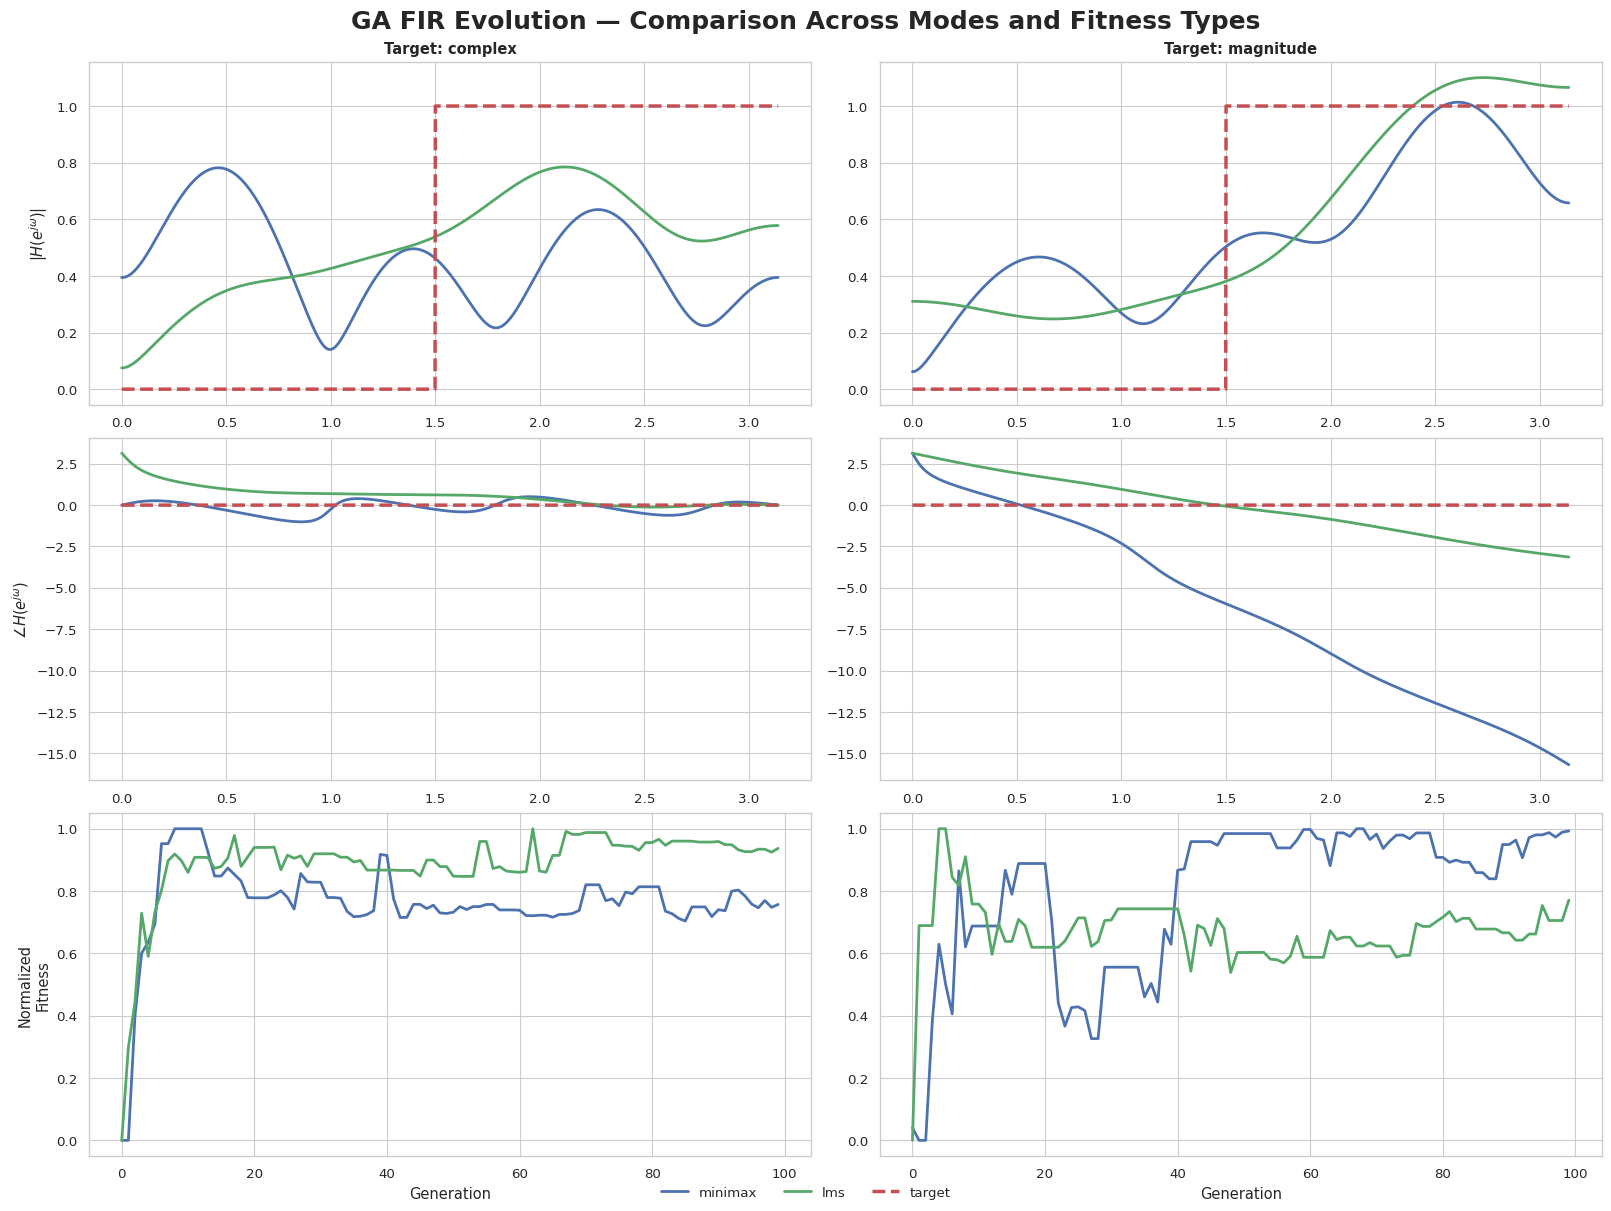

In [106]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR(b_minimax)
    _, H_lms, _ = compute_FR(b_lms)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit(b, target, mode=mode)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit(b, target, mode=mode)
                          for b in results[(mode, "lms")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

### Observations
As it was expected, computing the fitness over the complex response allows our solutions to get close both in magnitude and phase. If instead we just care about the magnitude, we can reach much better convergence to the desired response, at the price of a completely arbitrary phase. The papers only care about the latter, but it was interesting to showcase this distinction nonetheless.

## **1. CSD-compatible GA** by _A.Lee, M. Ahmadi, G.A. Jullien, et al._

Designing a filter using infinite-precision real coefficients, like we did in the previous example, inevitably leads to _quantization_ and _truncation_ errors when implementing them in finite-precision hardware. It is only natural to ask ourselves if there is a way to _directly_ evolve these filters in their _"native"_ representation, such that the evolved solution is as close as possible to its real world counterpart. Not only that, is it also possible to automatically evolve a solution that will produce the _least amount of complexity_ in the final filter hardware? This is the question the chosen paper tries to answer. Regarding the _finite precision_ requirement, we will work with a **finite wordlength** chosen by the filter designer. In order to _minimize the complexity_ of the resulting circuitry, a particular set of constraints will be used called **CSD representation**. Additionally, a **maximum number of nonzero digits**  $N_{\text{digits}}$ within each coefficient will be chosen by the designer to further limit the complexity of the filter.

### CSD theory

CSD (Canonical Signed Digit) is a **radix‑2 signed‑digit number system** where each digit takes values: $d_k \in \{-1, 0, +1\}$, and is associated with the power‑of‑two term $2^k$.
CSD imposes a structural constraint, namely that **no two adjacent digits may be non‑zero**: $d_k \neq 0 \;\Rightarrow\; d_{k-1} = d_{k+1} = 0.$ This rule guarantees a **unique representation** with the **minimum possible Hamming weight** among all radix‑2 signed-digit expansions.

In an FIR filter,

$$
y[n] = \sum_{k=0}^{N-1} h[k]\,x[n-k],
$$

each multiplication becomes:

$$
h[k]\cdot x[n-k]=
(\sum_i d_{k,i} 2^{e_{k,i}})\cdot x[n-k]=
\sum_i d_{k,i}\,(x[n-k] \ll e_{k,i}),
$$

As such, using a CSD representation:
- **Multipliers vanish**
- Adds/subs are **minimized** due to the minimal Hamming weight.

In FIR filters this yields the smallest, fastest, and most power‑efficient hardware implementation of fixed coefficients.



#### Encodings
The paper propose 2 different encodings for each coefficient $h[k]$: **ternary** and **mixed**.

- In the **ternary** encoding, a filter coefficient is represented by a string of ternary digits. Each of the ternary digits
corresponds to a power-of-two (POT) number. Thus, the i-th coefficient of the filter is: $h_i=d_{0_i} \times 2^0 + d_{1_i} \times 2^{-1} + \dots + d_{m_i} \times 2^{-m_i}$. This means that we waste space encoding unused powers of 2. The length of each ternary string is equivalent to the wordlength of the filter coefficient.

- In the **mixed** encoding, each filter coefficient is represented by the combination of ternary digits and binary strings. In this case, the string encodes directly the desired POT exponents. In fact, the string's structure is as follows: $|s_0|b_{0_1} \dots b_{0_p}| \dots |s_m|b_{m_1} \dots b_{m_p}|$, where $s_i \in \{-1, 1\}$, $b_{i_j} \in \{0,1\}$, and $p$ is the precision with which we encode the POT exponent. Thus, the i-th coefficient of the filter is: $h_i=s_{0_i} \times 2^{k_{0_i}} + \dots + s_{m_i} \times 2^{k_{m_i}}$, where $k_{j_i}$ is the real number encoded by $b_{j_{1_i}} \dots b_{j_{p_i}}$. The wordlength of a filter coefficient is bounded by the maximum value of the exponent, $(m_i + 1)$.  Only non-zero POT digits are encoded for mixed encoding, whereas the whole filter coefficient including the zero digits is encoded for ternary encoding.

Unfortunately, the paper does not properly describe how the mixed encoding is actually implemented and how mutation and crossover would work with it, never mind what it would mean for an individual to be in CSD form. For this reason, we will only implement and test the ternary encoding.

### Implementation

Since we already wrote a complete GA for the real-valued case, this change in genome will only require a few modifications.

#### Utilities

As the first order of business, we write some utilities to make our lives easier. Since the genome of an individual is a single list of symbols, but each coefficient has to be treated separately, we implement some functions to extract and merge coefficients automatically and convert them to real numbers.

In [107]:
def genomeToCoeffList(genome, wordlength):
    return [genome[i:(i + wordlength)] for i in range(0, len(genome), wordlength)]

def coeffListToGenome(coeffs):
    genome = []
    for coeff in coeffs:
        genome.extend(coeff)
    return genome

def CSDtoReal(CSDcoeff):
    r = 0
    for i in range(0, len(CSDcoeff)):
        r += CSDcoeff[i]*(2 ** (-i))
    return r

def genomeToRealCoeffList(genome, wordlength):
    return [CSDtoReal(coeff) for coeff in genomeToCoeffList(genome, wordlength)]

#### CSD Check
We write a utility function to make sure an individual is CSD-encoded and, in general, valid.

In the **ternary** case, an individual is CSD-compliant if, for each coefficient:
- Given two adjacent digits $d_i, d_{i+1} \quad d_i \times d_{i+1} = 0$
- The number of nonzero digits doesn't exceed a provided $N_{\text{digits}}$

In [108]:
def isTernaryIndividualCSD(genome, wordlength, N_digits):
    broken_coeffs = []
    coeffs = genomeToCoeffList(genome, wordlength)
    for i in range (0, len(coeffs)):
        coeff = coeffs[i]
        if len([symbol for symbol in coeff if symbol not in [0]]) > N_digits:
            broken_coeffs.append(i)
            continue
        for j in range (0, len(coeff)-1):
            if coeff[j]*coeff[j+1] != 0:
                broken_coeffs.append(i)
                break
    return (True, []) if len(broken_coeffs) == 0 else (False, broken_coeffs)

#### Initialization
As per the paper: _Each chromosome within a population is cascaded of
encoded filter coefficients, such that each coefficient is
initialized by a non-zero power-of-two digit._ This translates into setting a single bit to nonzero per coefficient in the ternary case.

In [109]:
def init_CSD_coeff(wordlength):
    coeff = [0] * wordlength
    coeff[random.randint(0, wordlength-1)] = random.choice([-1, 1])
    return coeff

def init_individual_CSD(order, wordlength):
    return coeffListToGenome([init_CSD_coeff(wordlength) for _ in range(0, order)])

def init_pop_CSD(N_chrom, order, wordlength):
    return [init_individual_CSD(order, wordlength) for _ in range(N_chrom)]

#### Mutation

For **ternary** encoding, a mutation is equal to a random choice between $\{-1, 0, 1\} \setminus \{symbol\}$. For the **mixed** encoding, the mutation follows the semantics of the encoding (this is a personal choice), thus, when mutating a sign symbol, the choice is still between $\{-1, 0, 1\} \setminus \{symbol\}$, while when mutating an exponent symbol the choice is a simple bit flip. _(We don't have to worry if a sign symbol is mutated to 0 since that is taken into account and the entire POT will be ignored even if the exponent is nonzero)_

In [110]:
def mut_ternary(individual, p_mut=0.01):
    mutated = []
    for symbol in individual:
        if random.random() < p_mut:
            choices = [-1, 0, 1]
            choices.remove(symbol)
            mutated.append(random.choice(choices))
        else:
            mutated.append(symbol)
    return mutated

#### Crossover
The paper specifies a two-point crossover strategy.

In [111]:
def twopoint_cross(p1, p2):
    indexes = random.sample(range(1, len(p1) - 1), 2)
    indexes.sort()
    return p1[:indexes[0]] + p2[indexes[0]:indexes[1]] + p1[indexes[1]:], p2[:indexes[0]] + p1[indexes[0]:indexes[1]] + p2[indexes[1]:]

#### Fitness
The fitness calculation remains mostly the same, except we immediately convert through the use of a helper function the ternary coefficients into real numbers. By doing this, we can make use of the previously defined error functions.

In [112]:
from functools import partial

def minimax_fit_CSD(individual, target, mode, wordlength):
    return minimax_fit(genomeToRealCoeffList(individual, wordlength), target, mode)

def lms_fit_CSD(individual, target, mode, wordlength):
    return lms_fit(genomeToRealCoeffList(individual, wordlength), target, mode)

def CSD_fit_to_real_fit(fitness, wordlength):
    return partial(fitness, wordlength=wordlength)


#### GA
Due to the addition of the $N_{\text{digits}}$ parameter we need to modify our GA function. Furthermore, since we do not perform the mutation in a way that is compatible with CSD, we follow the paper's instructions of checking the CSD validity of every child and retrying crossover and mutation until compliant. If the number of retries exceeds $N_{\text{max}}$, the child becomes a newly initialized individual.

In [113]:
def GA_CSD(N_chrom, generations, order, wordlength, target, fitness, N_digits, N_max, elitism=False, mode="complex"):
    best = []
    N_elites = int(N_chrom / 100 * 5) if elitism else 0

    # Population initialization
    pop = init_pop_CSD(N_chrom, order, wordlength)

    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode, wordlength), reverse=True)
        elites = pop[:N_elites]
        best.append(pop[0])
        for _ in range(N_chrom):
            p1 = pop[random.randint(0, len(pop) - 1)]
            p2 = pop[random.randint(0, len(pop) - 1)]
            c1, c2 = twopoint_cross(p1, p2)
            c1 = mut_ternary(c1)
            c2 = mut_ternary(c2)
            for n in range(0, N_max+1):
                is_c1_CSD, broken_coeffs_c1 = isTernaryIndividualCSD(c1, wordlength, N_digits)
                is_c2_CSD, broken_coeffs_c2 = isTernaryIndividualCSD(c2, wordlength, N_digits)
                if n == N_max:
                    c1_fixed = genomeToCoeffList(c1, wordlength)
                    c2_fixed = genomeToCoeffList(c2, wordlength)
                    for i in broken_coeffs_c1:
                        c1_fixed[i] = init_CSD_coeff(wordlength)
                    for i in broken_coeffs_c2:
                        c2_fixed[i] = init_CSD_coeff(wordlength)
                    c1 = coeffListToGenome(c1_fixed)
                    c2 = coeffListToGenome(c2_fixed)
                    break
                if not is_c1_CSD:
                    c1, _ = twopoint_cross(p1, p2)
                    c1 = mut_ternary(c1)
                    continue
                if not is_c2_CSD:
                    _, c2 = twopoint_cross(p1, p2)
                    c2 = mut_ternary(c2)
                    continue
                break
            pop.extend([c1, c2])
        pop = selection(pop, N_chrom - N_elites, CSD_fit_to_real_fit(fitness, wordlength), target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode, wordlength)))
    return best

### Testing a basic FIR filter
Before doing any side-by-side comparisons, we will see how the GA behaves on very simple filter design.

In [114]:
N_digits = 3
N_max = 20
worN = 1024
wordlength = 8

In [115]:
def compute_FR_CSD(individual, worN, wordlength):
    w, H = freqz(genomeToRealCoeffList(individual, wordlength), worN=worN)
    Ht = np.array([target(wi) for wi in w], dtype=complex)
    return w, H, Ht

#### Ideal high-pass filter

In [116]:
def target(w):
    return 1 if w >= 1.5 else 0

In [117]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, elitism=False,
                                        mode=mode)
    results[(mode, "lms")] = GA_CSD(N_chrom, generations, order, wordlength, target, lms_fit_CSD, N_digits, N_max, elitism=False,
                                    mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


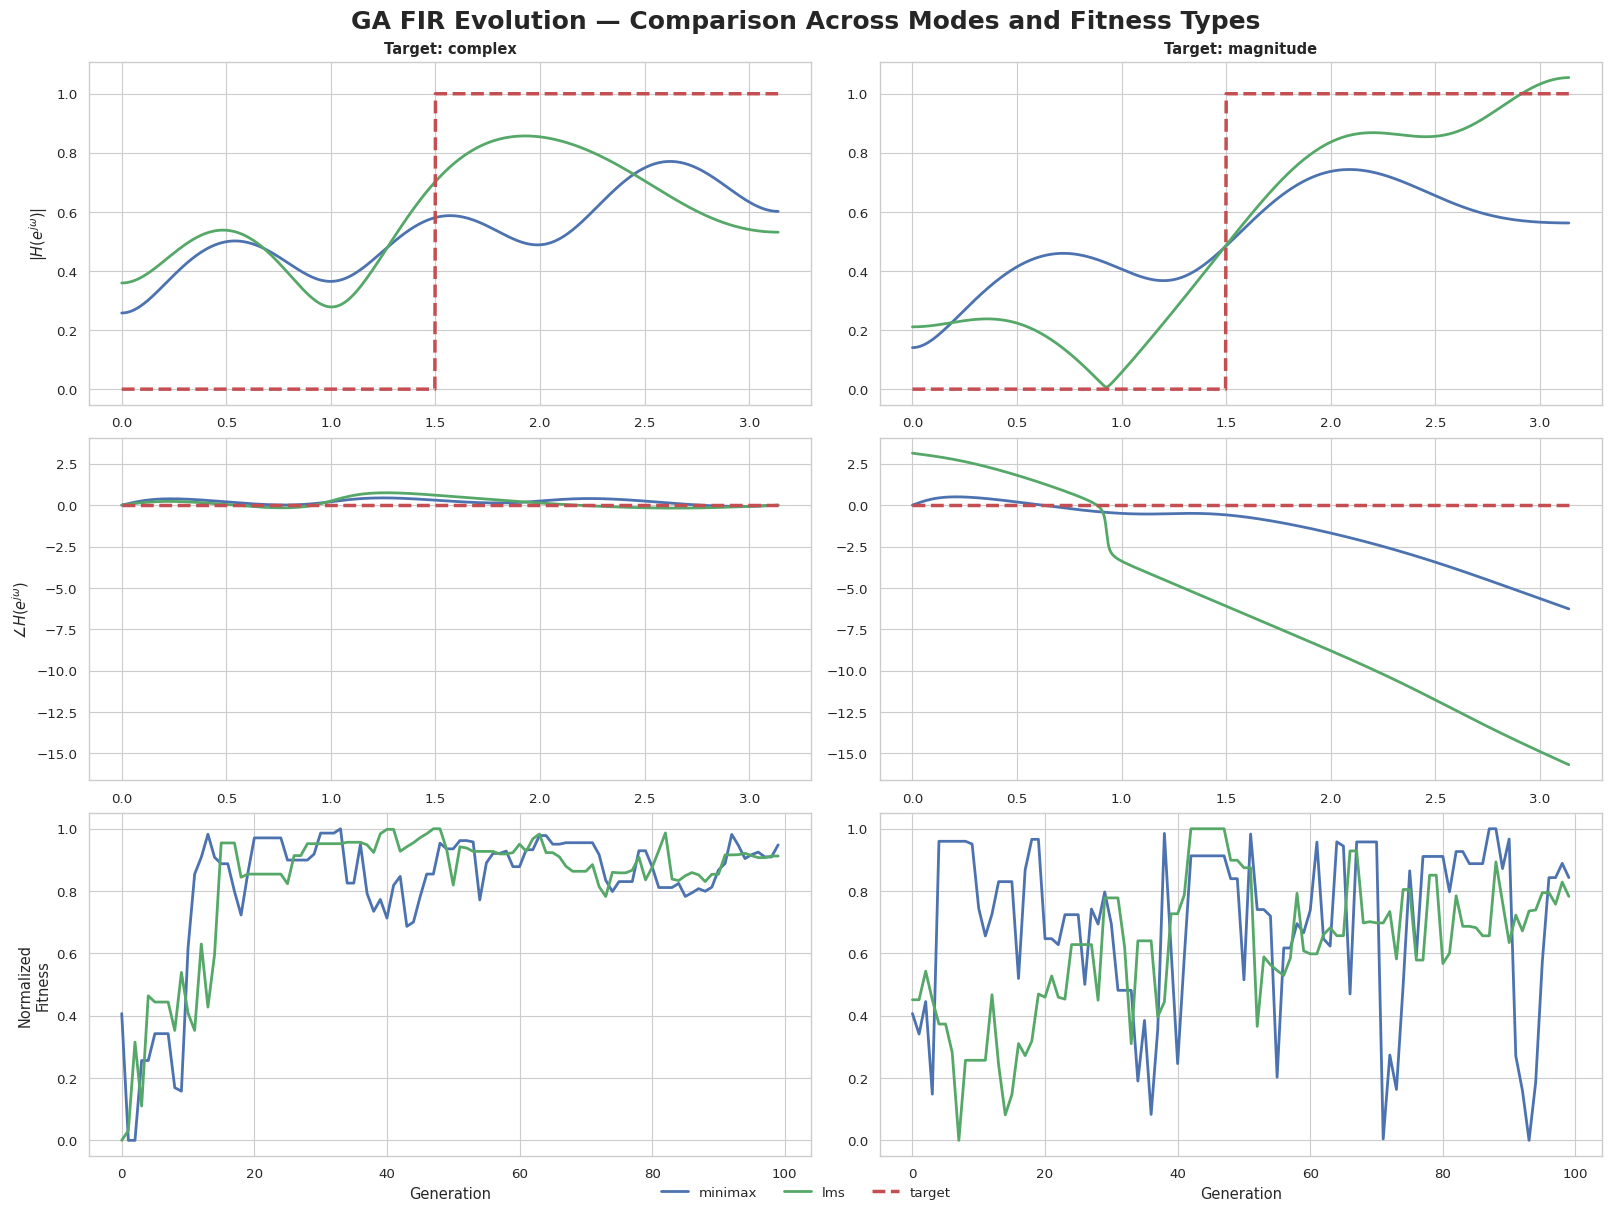

In [118]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax, worN, wordlength)
    _, H_lms, _ = compute_FR_CSD(b_lms, worN, wordlength)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode, wordlength)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode, wordlength)
                          for b in results[(mode, "lms")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

## **2. CSD-encoded GA w/ CSD-compliance**
We finish this study by implementing a couple of modifications over the original ternary GA. These will be:
- CSD-preserving mutation
- CSD-preserving one-point crossover
- Tournament selection
- Elitism

We will be able to keep most of the functions written so far.

### Implementation

#### Mutation

During the mutation of a ternary symbol, in order to preserve CSD compliance, there might be cases in which that would not be possible. This could be either because of the limit of nonzero digits, or because it would create a situation in which adjacent digits are nonzero. For this reason, we have chosen an aggressive mutation strategy that forces mutation by changing adjacent digits. This makes mutation less localized than a normal bit flip, but allows us to make it happen in more occasions than if we were to give up every time CSD compliance were about to be broken. The only case in which mutation doesn't happen even if it was supposed to, is if doing so would mean that $|\text{nonzero}| > N_{\text{digits}}$.

In [119]:
def mut_CSD(individual, wordlength, N_digits, p_mut=0.01):
    mutated = []
    for coeff in genomeToCoeffList(individual, wordlength):
        curr_d = len([symbol for symbol in coeff if symbol not in [0]])
        mutated_coeff = coeff

        for i in range(0, len(mutated_coeff)):
            if random.random() < p_mut:
                choices = [-1, 0, 1]
                choices.remove(mutated_coeff[i])
                choice = random.choice(choices)
                if mutated_coeff[i] != 0:
                    mutated_coeff[i] = choice
                    curr_d -= 0 if choice != 0 else 1
                    continue
                if curr_d < N_digits:
                    # Special case for first symbol
                    if i == 0:
                        if mutated_coeff[i+1] != 0:
                            mutated_coeff[i+1] = 0
                            curr_d -= 1
                        mutated_coeff[i] = choice
                        curr_d += 1
                        continue
                    # Special case for last symbol
                    if i == len(mutated_coeff)-1:
                        if mutated_coeff[i-1] != 0:
                            mutated_coeff[i-1] = 0
                            curr_d -= 1
                        mutated_coeff[i] = choice
                        curr_d += 1
                        continue
                    # Intermediate symbols
                    if mutated_coeff[i-1] != 0 and mutated_coeff[i+1] != 0:
                        mutated_coeff[i-1] = 0
                        curr_d -= 1
                        mutated_coeff[i+1] = 0
                        curr_d -= 1
                        mutated_coeff[i] = choice
                        curr_d += 1
                        continue
                    if mutated_coeff[i-1] != 0:
                        mutated_coeff[i-1] = 0
                        curr_d -= 1
                        mutated_coeff[i] = choice
                        curr_d += 1
                        continue
                    if mutated_coeff[i+1] != 0:
                        mutated_coeff[i+1] = 0
                        curr_d -= 1
                        mutated_coeff[i] = choice
                        curr_d += 1
                        continue
                    mutated_coeff[i] = choice
                    curr_d += 1
        mutated.append(mutated_coeff)
    return coeffListToGenome(mutated)

#### Crossover
By performing a generic n-point crossover between genomes, it's probable that a crossover point might be inside a coefficient, creating a partial swap. Analyzing the neighborhood of the crossover point, we might be able to "normalize" it by eliminating adjacent nonzero digits to make the crossover CSD compliant. A problem arises though when considering the $N_{\text{digits}}$ limit, as that could cause a big chunk of the coefficient to be filled with too many nonzero values, thus requiring an unspecified algorithm to zero enough digits for compliance. Since such algorithm is not obvious and could create all sorts of bias, we opt for a crossover between entire coefficients so that CSD compliance is guaranteed.

In [120]:
def onepoint_cross_CSD(p1, p2, wordlength):
    xover_point = random.randint(1, int(len(p1)/wordlength) - 1)
    xover_point *= wordlength
    return p1[:xover_point] + p2[xover_point:], p2[:xover_point] + p1[xover_point:]

#### Selection

In [121]:
def tournament_selection(pop, n_pop, fitness, target, mode, k=3):
    newpop = []
    while len(newpop) < n_pop:
        contestants = random.choices(population=pop, k=k)
        contestants.sort(key=lambda x: fitness(x, target, mode), reverse=True)
        newpop.append(contestants[0])
    return newpop

#### GA
Other than changing the mutation, crossover, and selection functions, the only real change is to remove the $N_{\text{max}}$ parameter from the GA. Elitism was already implemented before, so it's just enabled by default.

In [122]:
def GA_CSD2(N_chrom, generations, order, wordlength, target, fitness, N_digits, elitism=True, mode="complex"):
    best = []
    N_elites = int(N_chrom / 100 * 5) if elitism else 0

    # Population initialization
    pop = init_pop_CSD(N_chrom, order, wordlength)

    for _ in range(generations):
        pop.sort(key=lambda x: fitness(x, target, mode, wordlength), reverse=True)
        elites = pop[:N_elites]
        best.append(pop[0])
        for _ in range(N_chrom):
            p1 = pop[random.randint(0, len(pop) - 1)]
            p2 = pop[random.randint(0, len(pop) - 1)]
            c1, c2 = onepoint_cross_CSD(p1, p2, wordlength)
            c1, c2 = mut_CSD(c1, wordlength, N_digits), mut_CSD(c2, wordlength, N_digits)
            # OPTIONAL: uncomment to check if all individuals are CSD
            #if not isTernaryIndividualCSD(c1, wordlength, N_digits)[0] or not isTernaryIndividualCSD(c2, wordlength, N_digits)[0]:
            #    print(f"c1: {isTernaryIndividualCSD(c1, wordlength, N_digits)[0]}")
            #    print(f"c2: {isTernaryIndividualCSD(c2, wordlength, N_digits)[0]}")
            pop.extend([c1, c2])
        pop = selection(pop, N_chrom - N_elites, CSD_fit_to_real_fit(fitness, wordlength), target, mode)
        pop.extend(elites)
    if elitism: best.append(max(best, key=lambda x: fitness(x, target, mode, wordlength)))
    return best

### Testing a basic FIR filter
We test the GA on a simple high pass filter.

In [123]:
N_digits = 3
worN = 1024
wordlength = 8

In [124]:
def target(w):
    return 1 if w >= 1.5 else 0

In [125]:
results = {}  # results[(mode, metric)] = list of best individuals
for mode in modes:
    print(f"Running GA mode = {mode} ...")
    results[(mode, "minimax")] = GA_CSD2(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, mode=mode)
    results[(mode, "lms")] = GA_CSD2(N_chrom, generations, order, wordlength, target, lms_fit_CSD, N_digits, mode=mode)

print("✓ GA runs completed.")

Running GA mode = complex ...
Running GA mode = magnitude ...
✓ GA runs completed.


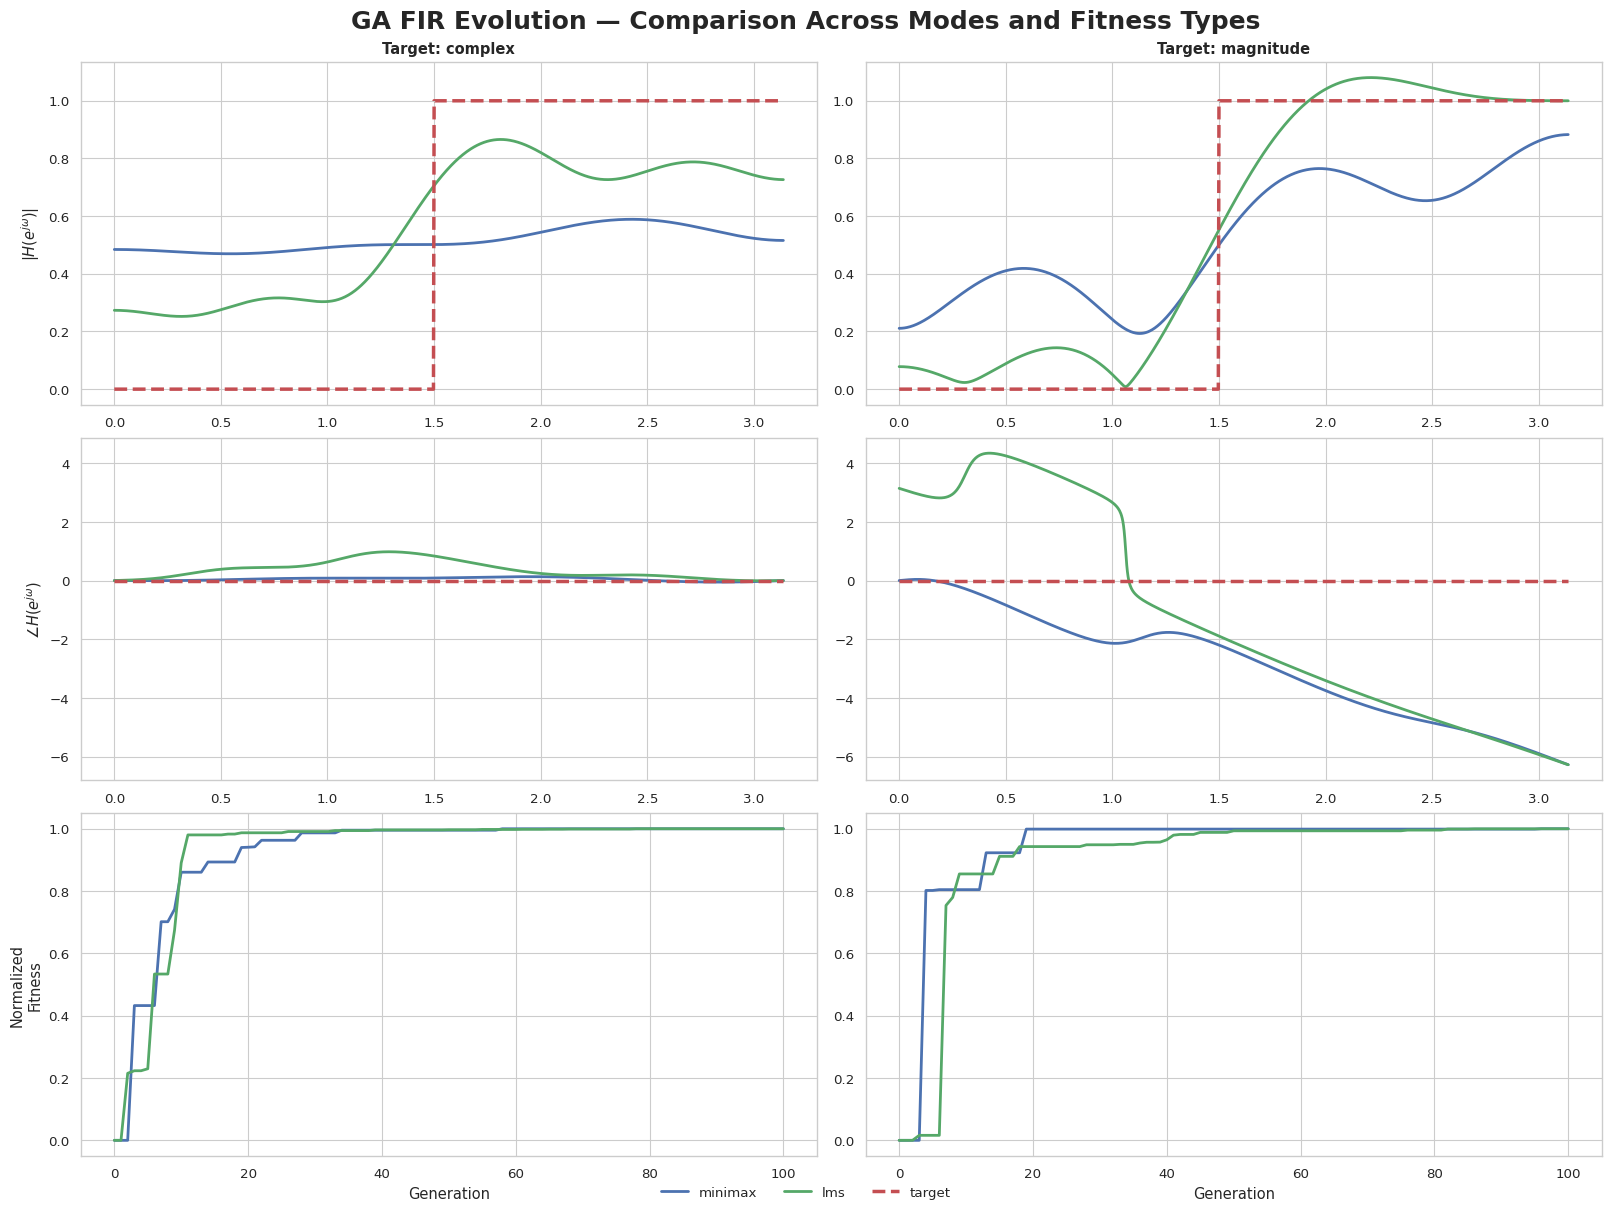

In [126]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=len(modes),
    figsize=(16, 12),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Comparison Across Modes and Fitness Types",
    fontsize=18,
    weight="bold"
)

for col, mode in enumerate(modes):
    # Final individuals
    b_minimax = results[(mode, "minimax")][-1]
    b_lms = results[(mode, "lms")][-1]

    # Frequency responses
    w, H_minimax, Ht = compute_FR_CSD(b_minimax, worN, wordlength)
    _, H_lms, _ = compute_FR_CSD(b_lms, worN, wordlength)

    # Magnitude / phase
    mag = {
        "minimax": np.abs(H_minimax),
        "lms": np.abs(H_lms),
        "target": np.abs(Ht),
    }

    ph = {
        "minimax": np.unwrap(np.angle(H_minimax)),
        "lms": np.unwrap(np.angle(H_lms)),
        "target": np.unwrap(np.angle(Ht)),
    }

    # Fitness histories
    fit = {
        "minimax": normalize([minimax_fit_CSD(b, target, mode, wordlength)
                              for b in results[(mode, "minimax")]]),
        "lms": normalize([lms_fit_CSD(b, target, mode, wordlength)
                          for b in results[(mode, "lms")]]),
    }
    gens = np.arange(len(fit["minimax"]))

    # ------------------ Magnitude ------------------
    ax = axes[0, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, mag[k], color=COLORS[k], lw=2, label=k)

    ax.plot(w, mag["target"], color=COLORS["target"],
            lw=2.5, ls="--", label="target")

    ax.set_title(f"Target: {mode}", weight="bold")
    if col == 0:
        ax.set_ylabel(r"$|H(e^{j\omega})|$")

    # ------------------ Phase ------------------
    ax = axes[1, col]
    for k in ["minimax", "lms"]:
        ax.plot(w, ph[k], color=COLORS[k], lw=2)

    ax.plot(w, ph["target"], color=COLORS["target"],
            lw=2.5, ls="--")

    if col == 0:
        ax.set_ylabel(r"$\angle H(e^{j\omega})$")

    # ------------------ Fitness ------------------
    ax = axes[2, col]
    for k in ["minimax", "lms"]:
        ax.plot(gens, fit[k], color=COLORS[k], lw=2, label=k)

    ax.set_xlabel("Generation")
    if col == 0:
        ax.set_ylabel("Normalized\nFitness")

# Unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# --- equalize Y scale only for magnitude and phase plots ---
for r in (0, 1):
    ymins, ymaxs = zip(*(ax.get_ylim() for ax in axes[r, :]))
    ymin, ymax = min(ymins), max(ymaxs)
    for ax in axes[r, :]:
        ax.set_ylim(ymin, ymax)
# --------------------------------------------------------------

plt.show()

## GA Comparison
The paper that has been considered for this project presents some experimental results at the end. Unfortunately, it is not clear what target filter(s) were chosen, the size of the population, and other design/simulation parameters. For this reason, we will choose a **population** of 100, 300 **generations**, **wordlength** of 8 and **N_digits** of 3, using the **minimax** fitness.

What we will do is take 4 classic filter designs:
- High-pass filter
- Band-pass filter
- Gaussian low-pass filter
- Integrator

For each of them, we will run the GAs in magnitude mode and we will measure the maximum peak error for:
- 5 to 30 coefficients, for 100 generations
- 10 to 100 generations for 15 coefficients

### Setup

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [141]:
N_chrom = 100
N_digits = 3
N_max = 20
wordlength = 8
target = minimax_fit
mode = "magnitude"

In [142]:
def results_by_order():
    generations = 100
    results_order = {
        "GA_real": {},
        "GA_CSD": {},
        "GA_CSD2": {}
    }
    for order in range(5, 31, 5):
        best = GA(N_chrom, generations, order, target, minimax_fit, mode=mode)[-1]
        err = -minimax_fit(best, target, mode)
        results_order["GA_real"][order] = [best, err]
        best = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, mode=mode)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_order["GA_CSD"][order] = [best, err]
        best = GA_CSD2(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, mode=mode)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_order["GA_CSD2"][order] = [best, err]
    return results_order

def results_by_generation():
    order = 15
    results_gen = {
        "GA_real": {},
        "GA_CSD": {},
        "GA_CSD2": {}
    }
    for generations in range(10, 101, 10):
        best = GA(N_chrom, generations, order, target, minimax_fit, mode=mode)[-1]
        err = -minimax_fit(best, target, mode)
        results_gen["GA_real"][generations] = [best, err]
        best = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, mode=mode)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_gen["GA_CSD"][generations] = [best, err]
        best = GA_CSD2(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, mode=mode)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_gen["GA_CSD2"][generations] = [best, err]
    return results_gen

### 1. Ideal high-pass filter

In [143]:
def target(w):
    return 1 if w >= 1.5 else 0

In [134]:
results_order = results_by_order()
results_gen = results_by_generation()

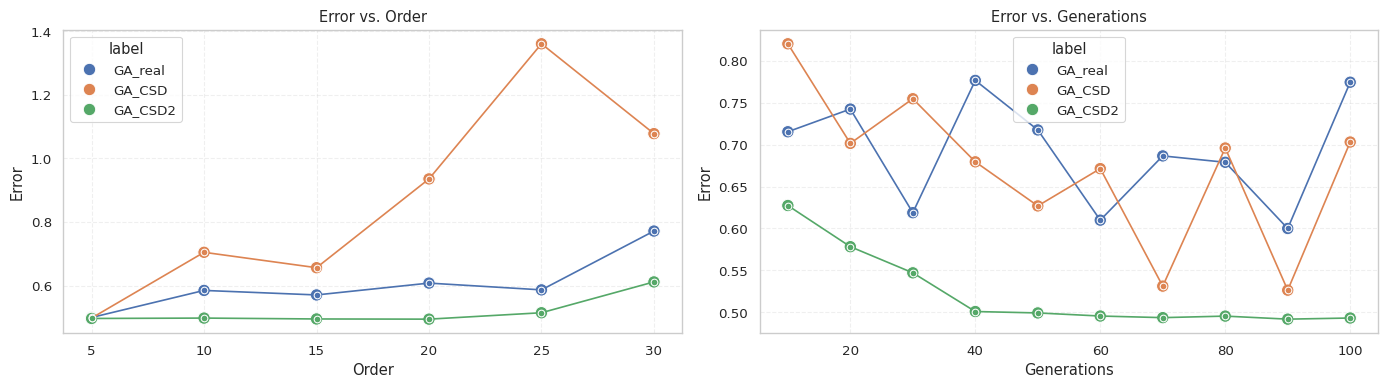

In [139]:
# -------- FIRST DATAFRAME (order) --------
rows_order = []
for label, by_order in results_order.items():
    for order, (_, err) in by_order.items():
        rows_order.append({"order": order, "error": err, "label": label})

df_order = pd.DataFrame(rows_order).sort_values("order")


# -------- SECOND DATAFRAME (generations) --------
rows_gen = []
for label, by_order in results_gen.items():
    for generations, (_, err) in by_order.items():
        rows_gen.append({"generations": generations, "error": err, "label": label})

df_gen = pd.DataFrame(rows_gen).sort_values("generations")


# -------- PLOT SIDE BY SIDE --------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- LEFT: Error vs Order ---
sns.scatterplot(ax=axes[0], data=df_order, x="order", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[0], data=df_order, x="order", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[0].set_title("Error vs. Order")
axes[0].set_xlabel("Order")
axes[0].set_ylabel("Error")
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- RIGHT: Error vs Generations ---
sns.scatterplot(ax=axes[1], data=df_gen, x="generations", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[1], data=df_gen, x="generations", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[1].set_title("Error vs. Generations")
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Error")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Ideal band-pass filter

In [144]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [145]:
results_order = results_by_order()
results_gen = results_by_generation()

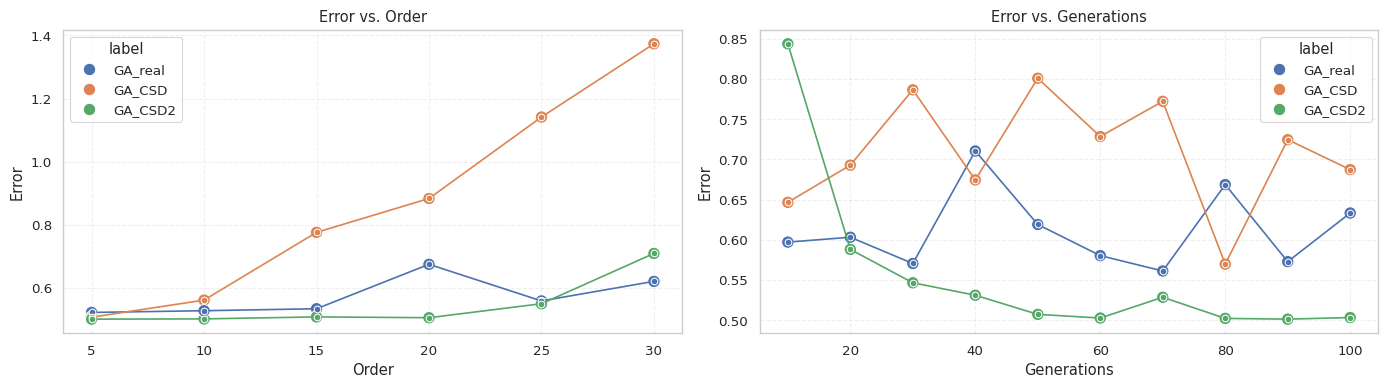

In [146]:
# -------- FIRST DATAFRAME (order) --------
rows_order = []
for label, by_order in results_order.items():
    for order, (_, err) in by_order.items():
        rows_order.append({"order": order, "error": err, "label": label})

df_order = pd.DataFrame(rows_order).sort_values("order")


# -------- SECOND DATAFRAME (generations) --------
rows_gen = []
for label, by_order in results_gen.items():
    for generations, (_, err) in by_order.items():
        rows_gen.append({"generations": generations, "error": err, "label": label})

df_gen = pd.DataFrame(rows_gen).sort_values("generations")


# -------- PLOT SIDE BY SIDE --------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- LEFT: Error vs Order ---
sns.scatterplot(ax=axes[0], data=df_order, x="order", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[0], data=df_order, x="order", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[0].set_title("Error vs. Order")
axes[0].set_xlabel("Order")
axes[0].set_ylabel("Error")
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- RIGHT: Error vs Generations ---
sns.scatterplot(ax=axes[1], data=df_gen, x="generations", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[1], data=df_gen, x="generations", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[1].set_title("Error vs. Generations")
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Error")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Ideal differentiator

In [147]:
def target(w):
    return w

In [148]:
results_order = results_by_order()
results_gen = results_by_generation()

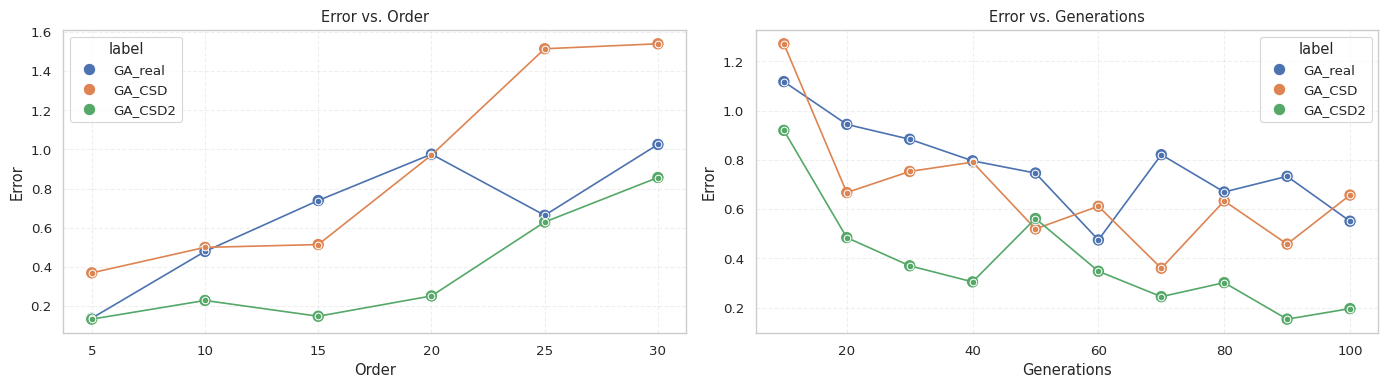

In [149]:
# -------- FIRST DATAFRAME (order) --------
rows_order = []
for label, by_order in results_order.items():
    for order, (_, err) in by_order.items():
        rows_order.append({"order": order, "error": err, "label": label})

df_order = pd.DataFrame(rows_order).sort_values("order")


# -------- SECOND DATAFRAME (generations) --------
rows_gen = []
for label, by_order in results_gen.items():
    for generations, (_, err) in by_order.items():
        rows_gen.append({"generations": generations, "error": err, "label": label})

df_gen = pd.DataFrame(rows_gen).sort_values("generations")


# -------- PLOT SIDE BY SIDE --------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- LEFT: Error vs Order ---
sns.scatterplot(ax=axes[0], data=df_order, x="order", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[0], data=df_order, x="order", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[0].set_title("Error vs. Order")
axes[0].set_xlabel("Order")
axes[0].set_ylabel("Error")
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- RIGHT: Error vs Generations ---
sns.scatterplot(ax=axes[1], data=df_gen, x="generations", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[1], data=df_gen, x="generations", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[1].set_title("Error vs. Generations")
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Error")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Gaussian low-pass filter

In [150]:
def target(w, sigma=0.5):
    return np.exp(-(sigma ** 2) * (w ** 2) / 2)

In [151]:
results_order = results_by_order()
results_gen = results_by_generation()

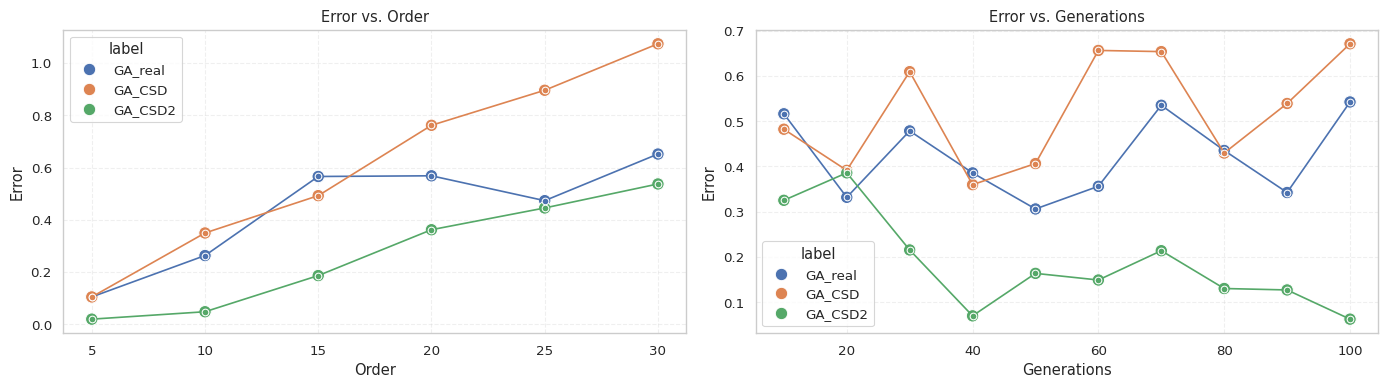

In [152]:
# -------- FIRST DATAFRAME (order) --------
rows_order = []
for label, by_order in results_order.items():
    for order, (_, err) in by_order.items():
        rows_order.append({"order": order, "error": err, "label": label})

df_order = pd.DataFrame(rows_order).sort_values("order")


# -------- SECOND DATAFRAME (generations) --------
rows_gen = []
for label, by_order in results_gen.items():
    for generations, (_, err) in by_order.items():
        rows_gen.append({"generations": generations, "error": err, "label": label})

df_gen = pd.DataFrame(rows_gen).sort_values("generations")


# -------- PLOT SIDE BY SIDE --------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- LEFT: Error vs Order ---
sns.scatterplot(ax=axes[0], data=df_order, x="order", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[0], data=df_order, x="order", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[0].set_title("Error vs. Order")
axes[0].set_xlabel("Order")
axes[0].set_ylabel("Error")
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- RIGHT: Error vs Generations ---
sns.scatterplot(ax=axes[1], data=df_gen, x="generations", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[1], data=df_gen, x="generations", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[1].set_title("Error vs. Generations")
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Error")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Final Remarks

As we can see from the previous comparisons, it is clear that the enhanced CSD GA displays the best performance overall. Certainly, as we have also seen in the relative fitness graphs, elitism helps a lot improving the convergence speed and allows us to make much better use of the number of generations. This can be further shown by evolving all our GAs with elitism:

In [153]:
def results_by_order():
    generations = 100
    results_order = {
        "GA_real": {},
        "GA_CSD": {},
        "GA_CSD2": {}
    }
    for order in range(5, 31, 5):
        best = GA(N_chrom, generations, order, target, minimax_fit, mode=mode, elitism=True)[-1]
        err = -minimax_fit(best, target, mode)
        results_order["GA_real"][order] = [best, err]
        best = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, mode=mode, elitism=True)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_order["GA_CSD"][order] = [best, err]
        best = GA_CSD2(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, mode=mode, elitism=True)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_order["GA_CSD2"][order] = [best, err]
    return results_order

def results_by_generation():
    order = 15
    results_gen = {
        "GA_real": {},
        "GA_CSD": {},
        "GA_CSD2": {}
    }
    for generations in range(10, 101, 10):
        best = GA(N_chrom, generations, order, target, minimax_fit, mode=mode, elitism=True)[-1]
        err = -minimax_fit(best, target, mode)
        results_gen["GA_real"][generations] = [best, err]
        best = GA_CSD(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, N_max, mode=mode, elitism=True)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_gen["GA_CSD"][generations] = [best, err]
        best = GA_CSD2(N_chrom, generations, order, wordlength, target, minimax_fit_CSD, N_digits, mode=mode, elitism=True)[-1]
        err = -minimax_fit_CSD(best, target, mode, wordlength)
        results_gen["GA_CSD2"][generations] = [best, err]
    return results_gen

In [154]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [155]:
results_order = results_by_order()
results_gen = results_by_generation()

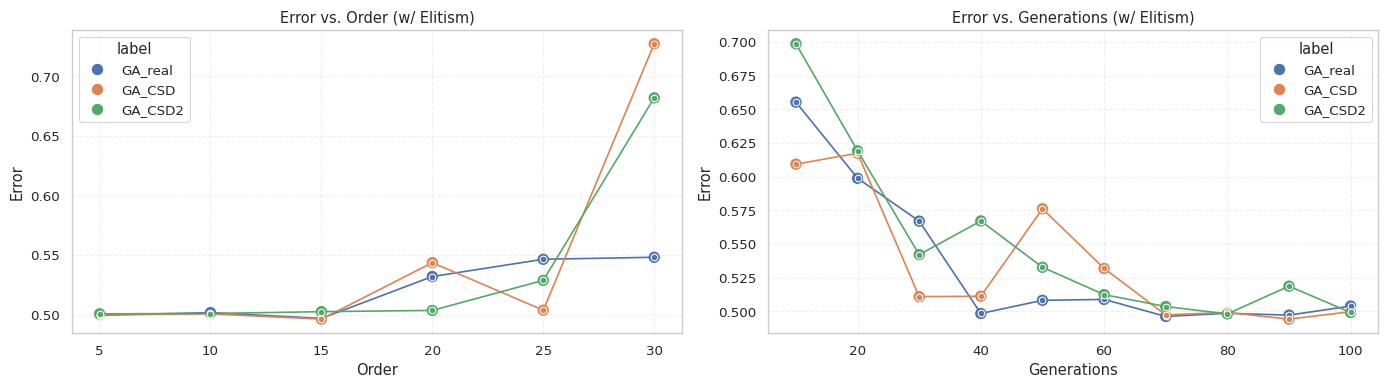

In [157]:
# -------- FIRST DATAFRAME (order) --------
rows_order = []
for label, by_order in results_order.items():
    for order, (_, err) in by_order.items():
        rows_order.append({"order": order, "error": err, "label": label})

df_order = pd.DataFrame(rows_order).sort_values("order")


# -------- SECOND DATAFRAME (generations) --------
rows_gen = []
for label, by_order in results_gen.items():
    for generations, (_, err) in by_order.items():
        rows_gen.append({"generations": generations, "error": err, "label": label})

df_gen = pd.DataFrame(rows_gen).sort_values("generations")


# -------- PLOT SIDE BY SIDE --------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- LEFT: Error vs Order ---
sns.scatterplot(ax=axes[0], data=df_order, x="order", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[0], data=df_order, x="order", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[0].set_title("Error vs. Order (w/ Elitism)")
axes[0].set_xlabel("Order")
axes[0].set_ylabel("Error")
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- RIGHT: Error vs Generations ---
sns.scatterplot(ax=axes[1], data=df_gen, x="generations", y="error",
                hue="label", palette="deep", s=80)
sns.lineplot(ax=axes[1], data=df_gen, x="generations", y="error",
             hue="label", palette="deep", marker="o", legend=False)

axes[1].set_title("Error vs. Generations (w/ Elitism)")
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Error")
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

The addition of elitism radically changes the performance of the other GAs, making them much more competitive and, in the real case, even better (although, as we have previously said, real GA is not suitable for filter design).

Unlike the paper chosen for the project, the error of the generated filters does not seem to lower when increasing the number of coefficients. Unfortunately, due to the lack of details in the paper, we cannot ascribe this behavior to a specific implementation detail. \
In the unmodified CSD GA without elitism, we can see a clear increase in error when adding more and more coefficients. Since random mutations and crossover can easily break CSD compliance, increasing the order of the filter might make it less and less probable of having passable children, requiring a high number of resets, taking back the progress gained.